In [39]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('../data/nhanes_2015_2016.csv')
path = pd.read_csv('../data/cartwheel.csv')
df.head()
path.head()

,ID,Age,Gender,GenderGroup,Glasses,GlassesGroup,Height,Wingspan,CWDistance,Complete,CompleteGroup,Score
0,1,56,F,1,Y,1,62.0,61.0,79,Y,1,7
1,2,26,F,1,Y,1,62.0,60.0,70,Y,1,8
2,3,33,F,1,Y,1,66.0,64.0,85,Y,1,7
3,4,39,F,1,N,0,64.0,63.0,87,Y,1,10
4,5,27,M,2,N,0,73.0,75.0,72,N,0,4


In [2]:
keep = ['BMXWT', 'BMXHT', 'BMXBMI', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BMXWAIST']

In [3]:
df_BMX2 = df.loc[:, keep]

In [5]:
df_BMX2.head(15)

,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST
0,94.8,184.5,27.8,43.3,43.6,35.9,101.1
1,90.4,171.4,30.8,38.0,40.0,33.2,107.9
2,83.4,170.1,28.8,35.6,37.0,31.0,116.5
3,109.8,160.9,42.4,38.5,37.7,38.3,110.1
4,55.2,164.9,20.3,37.4,36.0,27.2,80.4
5,64.4,150.0,28.6,34.4,33.5,31.4,92.9
6,76.6,165.4,28.0,38.8,38.0,34.0,86.6
7,64.5,151.3,28.2,34.1,33.1,31.5,93.3
8,72.4,166.1,26.2,NaN,NaN,NaN,NaN
9,108.3,179.4,33.6,46.0,44.1,38.5,116.0


In [7]:
waist_median = df_BMX2['BMXWAIST'].median()

In [8]:
waist_median

np.float64(98.3)

In [10]:
df_BMX2 = df_BMX2[df_BMX2['BMXWAIST'] > waist_median]

In [13]:
print(df_BMX2.shape)
print(df.shape)

df_BMX2.head()

(2677, 7)
(5735, 28)


,BMXWT,BMXHT,BMXBMI,BMXLEG,BMXARML,BMXARMC,BMXWAIST
0,94.8,184.5,27.8,43.3,43.6,35.9,101.1
1,90.4,171.4,30.8,38.0,40.0,33.2,107.9
2,83.4,170.1,28.8,35.6,37.0,31.0,116.5
3,109.8,160.9,42.4,38.5,37.7,38.3,110.1
9,108.3,179.4,33.6,46.0,44.1,38.5,116.0


In [16]:
condition2 = df['BMXLEG'] < 32
condition1 = df['BMXWAIST'] > waist_median
df_BMX2 = df[condition2 & condition1]

In [17]:
df_BMX2.shape


(163, 28)

In [18]:
sns.set()

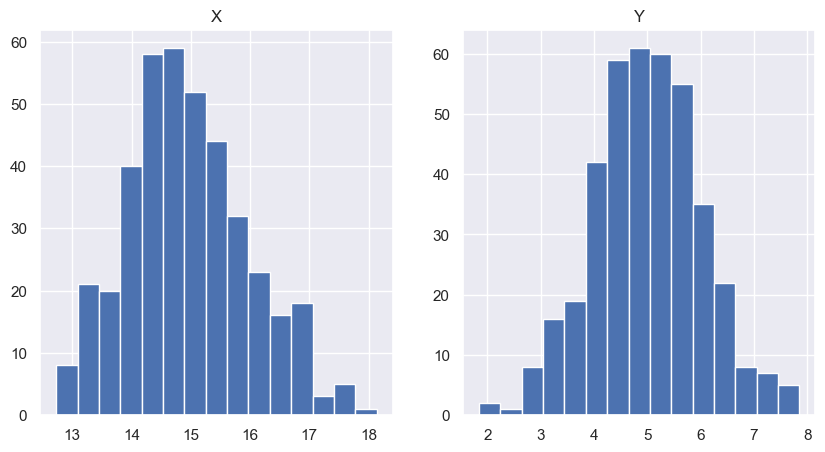

In [20]:
# Don't worry so much about what rho is doing here
# Just know if we have a rho of 1 then we will get a perfectly
# upward sloping line, and if we have a rho of -1, we will get 
# a perfectly downward slopping line. A rho of 0 will 
# get us a 'cloud' of points
r = 0.5

# Don't worry so much about the following three lines of code for now
# this is just getting the data for us to plot
mean = [15, 5]
cov = [[1, r], [r, 1]]
x, y = np.random.multivariate_normal(mean, cov, 400).T

# Adjust the figure size
plt.figure(figsize=(10,5))

# Plot the histograms of X and Y next to each other
plt.subplot(1,2,1)
plt.hist(x = x, bins = 15)
plt.title("X")

plt.subplot(1,2,2)
plt.hist(x = y, bins = 15)
plt.title("Y")

plt.show()

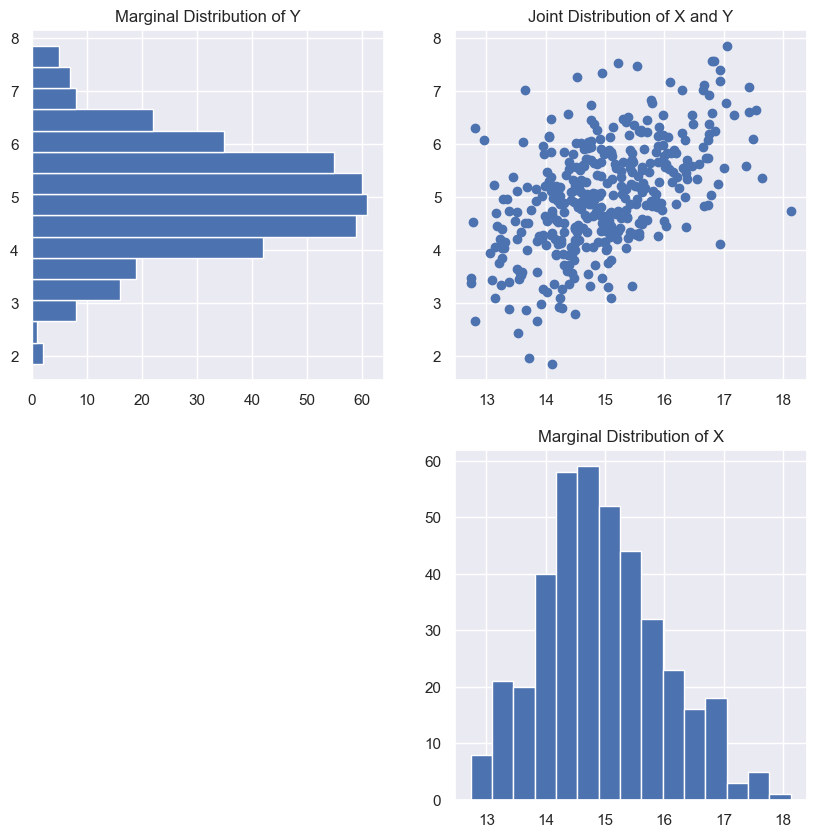

In [21]:
# Plot the data
plt.figure(figsize=(10,10))
plt.subplot(2,2,2)
plt.scatter(x = x, y = y)
plt.title("Joint Distribution of X and Y")

# Plot the Marginal X Distribution
plt.subplot(2,2,4)
plt.hist(x = x, bins = 15)
plt.title("Marginal Distribution of X")

# Plot the Marginal Y Distribution
plt.subplot(2,2,1)
plt.hist(x = y, orientation = "horizontal", bins = 15)
plt.title("Marginal Distribution of Y")

# Show the plots
plt.show()

In [25]:
assert np.max([2, 5, 3]) == 5

# using == 4 will get an error

<Axes: xlabel='BMXLEG', ylabel='BMXARML'>

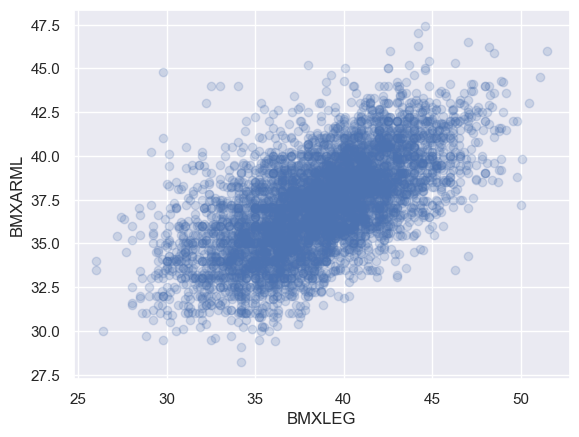

In [26]:
sns.regplot(x="BMXLEG", y="BMXARML", data=df, fit_reg=False, scatter_kws={"alpha": 0.2})

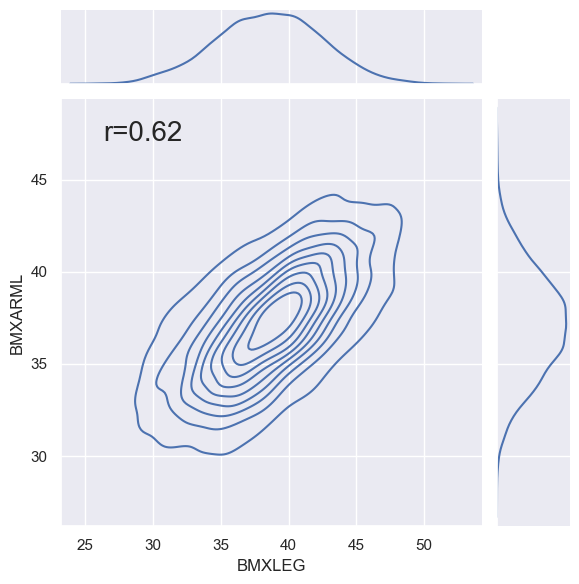

In [27]:
p = sns.jointplot(x="BMXLEG", y="BMXARML", kind='kde', data=df)
r = df[["BMXLEG", "BMXARML"]].corr().iloc[0, 1]
p.ax_joint.annotate("r=%.2f" % r, xy=(0.1, 0.9), xycoords="axes fraction", size=20);

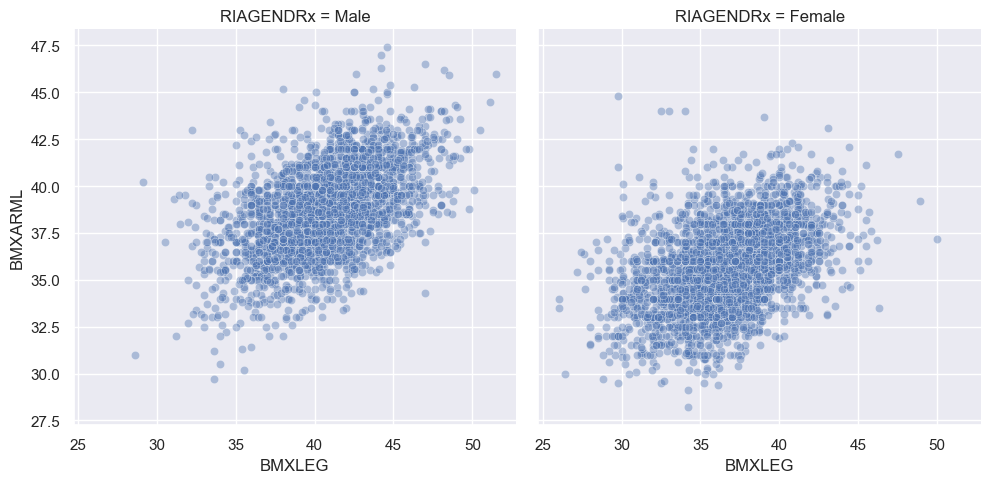

In [30]:
df["RIAGENDRx"] = df.RIAGENDR.replace({1: "Male", 2: "Female"}) 
sns.FacetGrid(df, col="RIAGENDRx", height=5).map(sns.scatterplot, "BMXLEG", "BMXARML", alpha=0.4).add_legend();

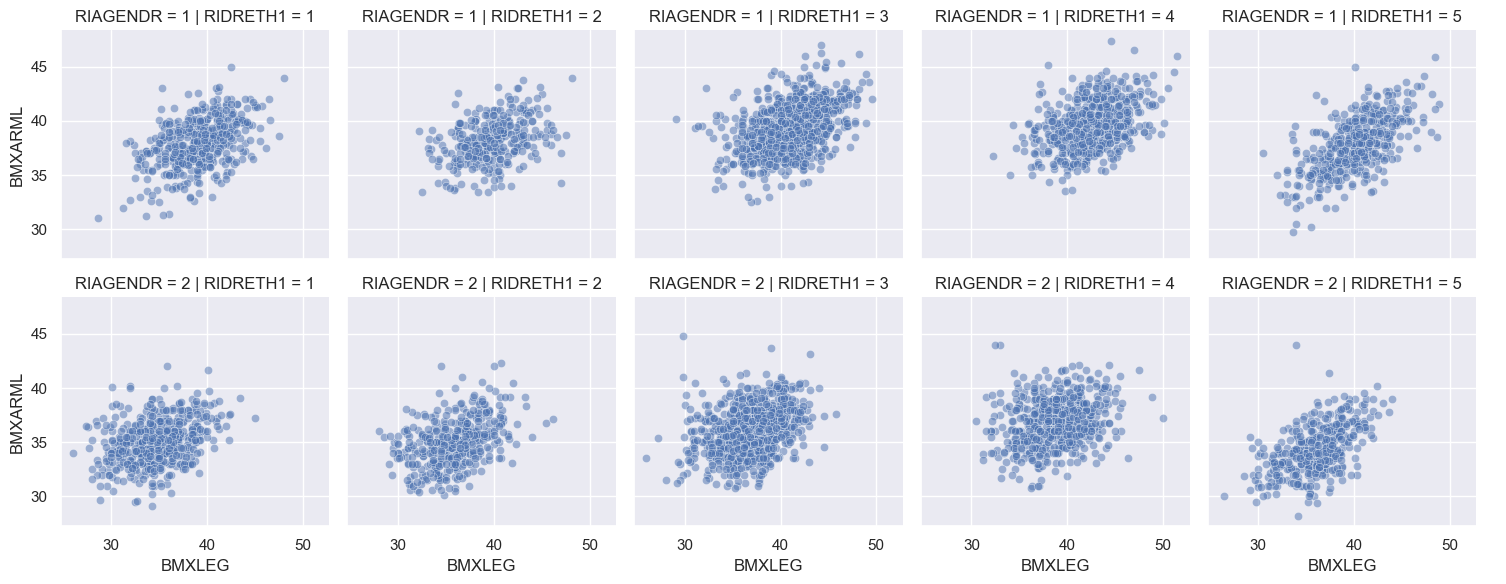

In [29]:
sns.FacetGrid(df, col="RIDRETH1",  row="RIAGENDR").map(sns.scatterplot, "BMXLEG", "BMXARML", alpha=0.5).add_legend();

In [33]:
pd.set_option('display.max_columns', 100)

In [34]:
path.head()

,ID,Age,Gender,GenderGroup,Glasses,GlassesGroup,Height,Wingspan,CWDistance,Complete,CompleteGroup,Score
0,1,56,F,1,Y,1,62.0,61.0,79,Y,1,7
1,2,26,F,1,Y,1,62.0,60.0,70,Y,1,8
2,3,33,F,1,Y,1,66.0,64.0,85,Y,1,7
3,4,39,F,1,N,0,64.0,63.0,87,Y,1,10
4,5,27,M,2,N,0,73.0,75.0,72,N,0,4


<Axes: xlabel='Height', ylabel='Wingspan'>

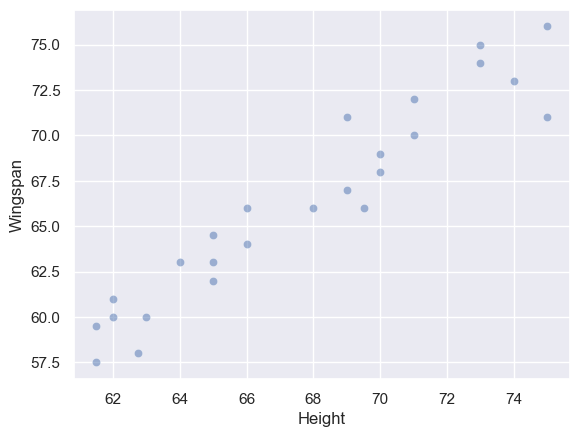

In [35]:
sns.scatterplot(x="Height", y="Wingspan", data=path, alpha=0.5)

In [62]:
Q1_D = path.CWDistance.quantile(0.25)
Q3_D = path.CWDistance.quantile(0.75)
IQR_D = Q3_D - Q1_D


Q1_W = path.Wingspan.quantile(0.25)
Q3_W = path.Wingspan.quantile(0.75)

IQR_W = Q3_W - Q1_W

path_IQR = path[(path.Wingspan > (Q3_W + 1.5 * IQR_W)) | (path.Wingspan < (Q1_W - 1.5 * IQR_W))]
path_IQR.head()

zscore = (path.Wingspan - path.Wingspan.mean()) / path.Wingspan.std()


In [63]:
print(IQR_D)
print(IQR_W)

22.0
9.0


In [43]:
path[zscore.abs() > 3]

,ID,Age,Gender,GenderGroup,Glasses,GlassesGroup,Height,Wingspan,CWDistance,Complete,CompleteGroup,Score


<Axes: xlabel='Height', ylabel='Wingspan'>

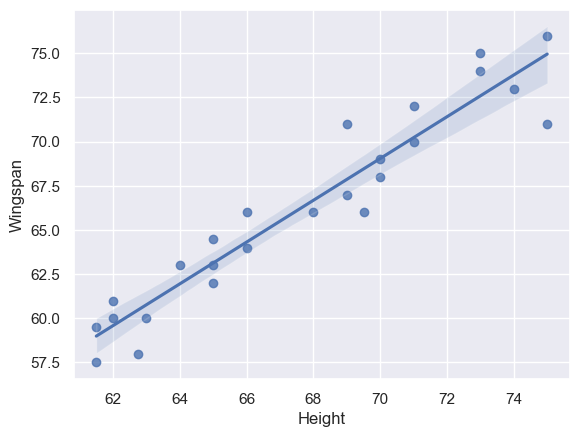

In [45]:
sns.regplot(x="Height", y="Wingspan", data=path)

In [60]:
path.groupby('Gender')[['Wingspan', 'Height']].corr()

Wingspan    Height
Gender                             
F      Wingspan  1.000000  0.892182
       Height    0.892182  1.000000
M      Wingspan  1.000000  0.809293
       Height    0.809293  1.000000

Strong positive linear association between height and wingspan, r ≈ 0.85. One person near 74" has a shorter wingspan than the trend predicts, but with n≈25 that's within normal variation rather than a clear outlier.

<Axes: xlabel='Wingspan', ylabel='CWDistance'>

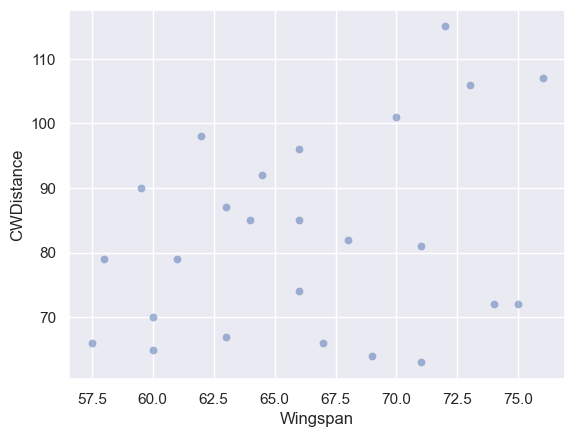

In [36]:
sns.scatterplot(x="Wingspan", y="CWDistance", data=path, alpha=0.5)

In [47]:
Q1 = path.CWDistance.quantile(0.25)
Q3 = path.CWDistance.quantile(0.75)

IQR = Q3 - Q1

path_IQR = path[(path.CWDistance > (Q3 + 1.5 * IQR)) | (path.CWDistance < (Q1 - 1.5 * IQR))]
path_IQR.head()




,ID,Age,Gender,GenderGroup,Glasses,GlassesGroup,Height,Wingspan,CWDistance,Complete,CompleteGroup,Score


In [48]:
zscore = (path.CWDistance - path.CWDistance.mean()) / path.CWDistance.std()
path[zscore.abs() > 3]

,ID,Age,Gender,GenderGroup,Glasses,GlassesGroup,Height,Wingspan,CWDistance,Complete,CompleteGroup,Score


<Axes: xlabel='Wingspan', ylabel='CWDistance'>

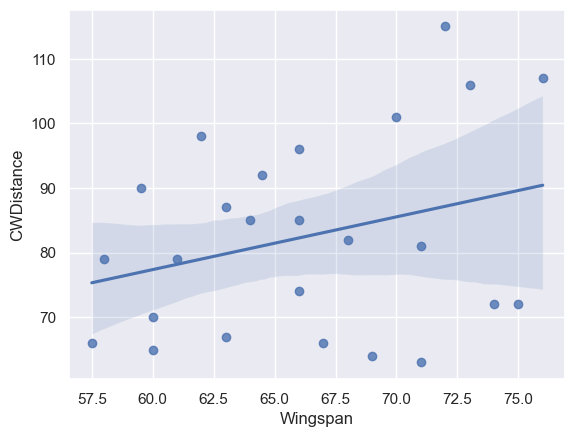

In [49]:
sns.regplot(x="Wingspan", y="CWDistance", data=path)

In [50]:
path[['Wingspan', 'CWDistance']].corr()

,Wingspan,CWDistance
Wingspan,1.000000,0.297662
CWDistance,0.297662,1.000000


<Axes: xlabel='Wingspan', ylabel='CWDistance'>

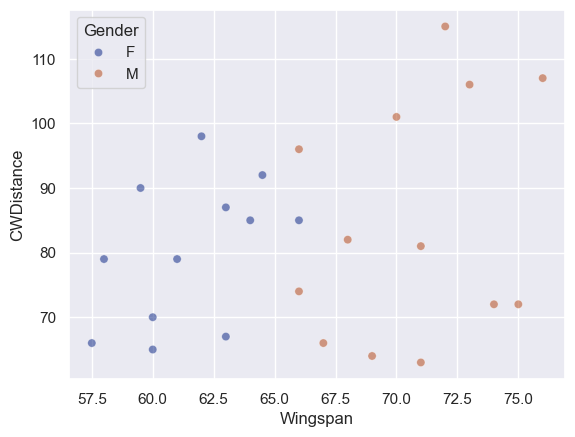

In [54]:
sns.scatterplot(x="Wingspan", y="CWDistance", data=path, alpha=0.5, hue="Gender", palette="dark")

In [56]:
path.groupby('Gender')[['Wingspan', 'CWDistance']].corr()

Wingspan  CWDistance
Gender                                 
F      Wingspan    1.000000    0.458121
       CWDistance  0.458121    1.000000
M      Wingspan    1.000000    0.274762
       CWDistance  0.274762    1.000000

C:\Users\HugoT\AppData\Local\Temp\ipykernel_16768\1072101156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Glasses", y="CWDistance", data=path, palette="dark")


<Axes: xlabel='Glasses', ylabel='CWDistance'>

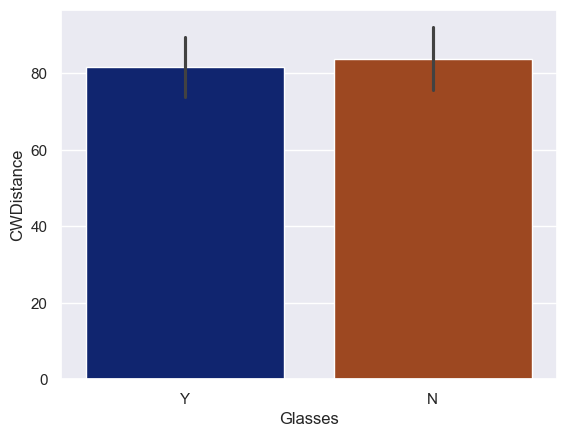

In [58]:
sns.barplot(x="Glasses", y="CWDistance", data=path, palette="dark")

<Axes: xlabel='Glasses', ylabel='CWDistance'>

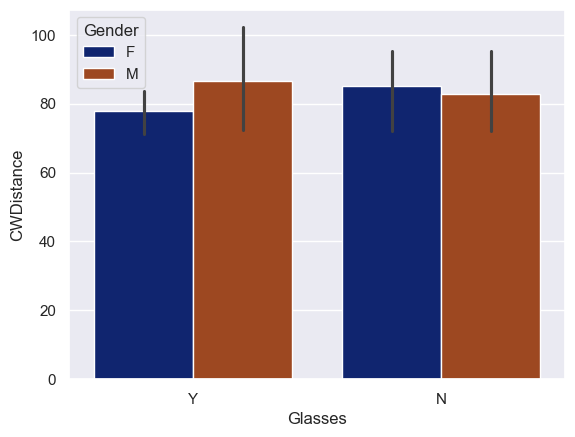

In [59]:
sns.barplot(x="Glasses", y="CWDistance", data=path, palette="dark" , hue="Gender")